# Video Game Sales Analysis Project
## Project Overview

This project analyzes historical video game sales data to identify the patterns that are most associated with commercial success. The goal is to support future campaign planning for the online store Ice.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
from scipy import stats as st
import math
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

## Data Loading and Initial Exploration

The dataset is loaded below, followed by a quick structural review of columns, types, and potential quality issues.

In [2]:
# Load the dataset
data = pd.read_csv('/datasets/games.csv')

In [3]:
# Display basic information about the dataset
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# Check for duplicate entries
print(data.duplicated().sum())

0


### Initial Findings

- The dataset contains 16,715 records.
- Column types include both object and float fields.
- `user_score` is stored as an object and requires conversion to numeric for quantitative analysis.
- `critic_score`, `user_score`, and `rating` contain substantial missingness, indicating many games were not fully reviewed or rated.

## Data Preparation

### Standardizing Column Names

In [5]:
# Convert column names to lowercase
data.columns = [x.lower() for x in data.columns]

In [6]:
# Verify the changes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### 2.2 Data Type Conversion

In [7]:
# Check current data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [8]:
# cleaning up data
# user_score is an 'object' which makes it hard to manipulate, converting to float64
# user_score is an object because it contains 'tbd', converting all tbds to null (score of 0 would affect analysis)
print(data['user_score'].head(10)) #before
data['user_score'] = data['user_score'].replace('tbd', np.nan)
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')
print(data['user_score'].head(10)) #after


0      8
1    NaN
2    8.3
3      8
4    NaN
5    NaN
6    8.5
7    6.6
8    8.4
9    NaN
Name: user_score, dtype: object
0    8.0
1    NaN
2    8.3
3    8.0
4    NaN
5    NaN
6    8.5
7    6.6
8    8.4
9    NaN
Name: user_score, dtype: float64


### 2.3 Handling Missing Values

In [9]:
# Checking how many missing values there are in each row
print(data.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [10]:
# Calculate percentage of missing values
print(data.isna().sum() / len(data) * 100)

name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64


In [11]:
# Analyze patterns in missing values
# Group by year and count missing values for the three columns of interest

# extract just the critic rating, user rating, and game rating into a dataframe
missing_by_year = data.groupby('year_of_release')[['critic_score', 'user_score', 'rating']].apply(lambda x: x.isna().sum())
games_per_year = data.groupby('year_of_release').size() # Get total games per year for context
missing_percentages = missing_by_year.div(games_per_year, axis=0) * 100 # translates number of missing ratings to %missing
missing_percentages['total_games'] = games_per_year # Add total games column for reference

print("Missing values by year (as percentages):")
print(missing_percentages.round(2))  # Round to 2 decimal places for readability

Missing values by year (as percentages):
                 critic_score  user_score  rating  total_games
year_of_release                                               
1980.0                 100.00      100.00  100.00            9
1981.0                 100.00      100.00  100.00           46
1982.0                 100.00      100.00  100.00           36
1983.0                 100.00      100.00  100.00           17
1984.0                 100.00      100.00  100.00           14
1985.0                  92.86       92.86   92.86           14
1986.0                 100.00      100.00  100.00           21
1987.0                 100.00      100.00  100.00           16
1988.0                  93.33       93.33   93.33           15
1989.0                 100.00      100.00  100.00           17
1990.0                 100.00      100.00  100.00           16
1991.0                 100.00      100.00  100.00           41
1992.0                  97.67       97.67   95.35           43
1993.0        

In [12]:
# Handle missing values based on analysis
# missing values that prevent analysis
print("1. Removing games with missing essential information:")
print(f"   - Games missing name: {data['name'].isna().sum()}")
print(f"   - Games missing genre: {data['genre'].isna().sum()}")
print(f"   - Games missing year: {data['year_of_release'].isna().sum()}")
# Remove games missing essential categorical data
data_clean = data.dropna(subset=['name', 'genre', 'year_of_release'])
print(f"   → Removed {len(data) - len(data_clean)} games")
print(f"   → Remaining dataset: {len(data_clean)} games\n")
#keep NaN - indicates game simply wasn't reviewed
#user_score was cleaned up earlier
#missing name/genre/platforms are omitted in relevant calcs

data = data_clean.copy()
print(f"\nFinal cleaned dataset: {len(data)} games")
print("Missing value summary after cleaning:")
print(data.isna().sum())

# Calculate total sales for later analysis
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

# Compare sales for games with and without critic scores
games_with_critic = data[data['critic_score'].notna()]
games_without_critic = data[data['critic_score'].isna()]

# print findings
print("Games WITH critic scores:")
print(f"Count: {len(games_with_critic)}")
print(f"Average total sales: {games_with_critic['total_sales'].mean():.2f}")
print(f"Median total sales: {games_with_critic['total_sales'].median():.2f}")

print("\nGames WITHOUT critic scores:")
print(f"Count: {len(games_without_critic)}")
print(f"Average total sales: {games_without_critic['total_sales'].mean():.2f}")
print(f"Median total sales: {games_without_critic['total_sales'].median():.2f}")

1. Removing games with missing essential information:
   - Games missing name: 2
   - Games missing genre: 2
   - Games missing year: 269
   → Removed 271 games
   → Remaining dataset: 16444 games


Final cleaned dataset: 16444 games
Missing value summary after cleaning:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64
Games WITH critic scores:
Count: 7983
Average total sales: 0.69
Median total sales: 0.25

Games WITHOUT critic scores:
Count: 8461
Average total sales: 0.39
Median total sales: 0.12


### Missing-Value Rationale

Missing review and rating fields likely reflect games with limited review coverage or incomplete reporting. These values were preserved as `NaN` for score-based analyses, while rows missing essential identifiers (`name`, `genre`, or `year_of_release`) were removed because they are not analytically reliable.

### 2.4 Calculate Total Sales

In [13]:
# Calculate total sales across all regions and put them in a different column
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']
data['total_sales'].head(10)

0    82.54
1    40.24
2    35.52
3    32.77
4    31.38
5    30.26
6    29.80
7    28.91
8    28.32
9    28.31
Name: total_sales, dtype: float64

## Sales Analysis

### Temporal Analysis of Game Releases

The following section examines release volume over time to establish data coverage and support the forecasting window selection.

In [14]:
# Create a DataFrame with game releases by year
release_per_year = data['year_of_release'].dropna().value_counts().sort_index() #ignore games without years, sort the years
print(release_per_year.head())

1980.0     9
1981.0    46
1982.0    36
1983.0    17
1984.0    14
Name: year_of_release, dtype: int64


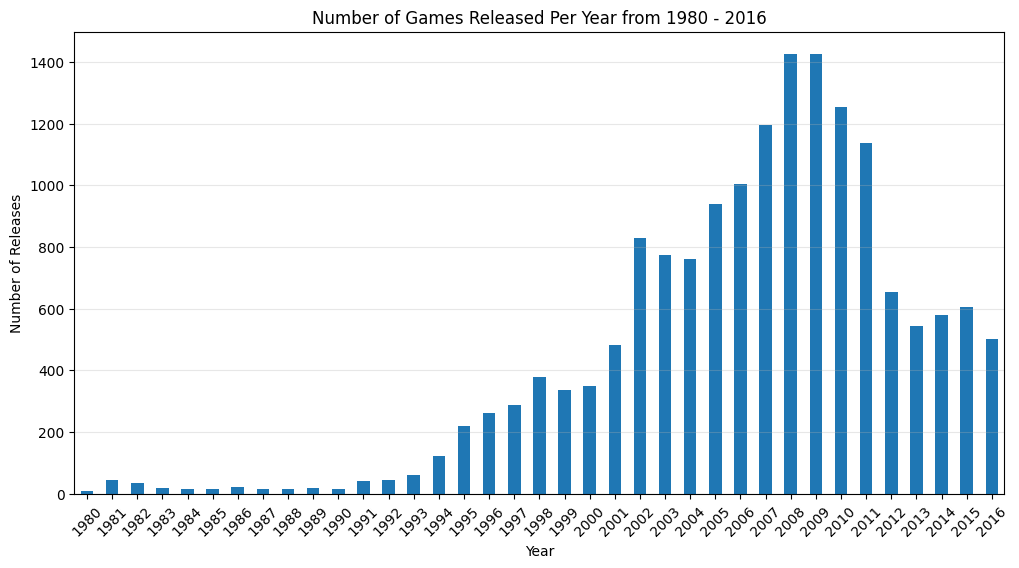

In [15]:
# setting up the graph data
release_graph = pd.DataFrame({'Release': release_per_year, 
                              'Year': release_per_year.index.astype(int)})
# Creating the graph, don't need the legend, everything else is standard creation of labels
release_graph.plot(x='Year', y='Release', kind='bar', figsize=(12,6), title="Number of Games Released Per Year from 1980 - 2016",
                   ylabel = 'Number of Releases', xlabel = 'Year', legend=False)
plt.grid(axis='y', alpha=0.3) #add gridmarks as the graph is wide + makes it easier to discern differences
plt.xticks(rotation=45) #legibility, numbers would be too close together otherwise
plt.show()


In [16]:
# Display summary statistics for each year
print("Overall Release Statistics")
print(release_per_year.describe())

Overall Release Statistics
count      37.000000
mean      444.432432
std       451.604334
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
Name: year_of_release, dtype: float64


### Temporal Takeaways

- Release volume peaks around 2008-2009 and declines after 2012.
- The long-term pattern shows growth through the early 2000s followed by periodic surges.
- The 2012-2016 range still provides enough observations to inform 2017 planning when treated as a multi-year window.

### Platform Sales Analysis Over Time

This section compares platform-level sales across years to identify declining systems, durable performers, and lifecycle behavior.

In [17]:
# Calculate total sales by platform and year
sales_per_platform_year = data.groupby(['platform', 'year_of_release'])['total_sales'].sum().to_frame('total_revenue')
print(sales_per_platform_year)

                          total_revenue
platform year_of_release               
2600     1980.0                   11.38
         1981.0                   35.68
         1982.0                   28.88
         1983.0                    5.84
         1984.0                    0.27
...                                 ...
XB       2008.0                    0.18
XOne     2013.0                   18.96
         2014.0                   54.07
         2015.0                   60.14
         2016.0                   26.15

[238 rows x 1 columns]


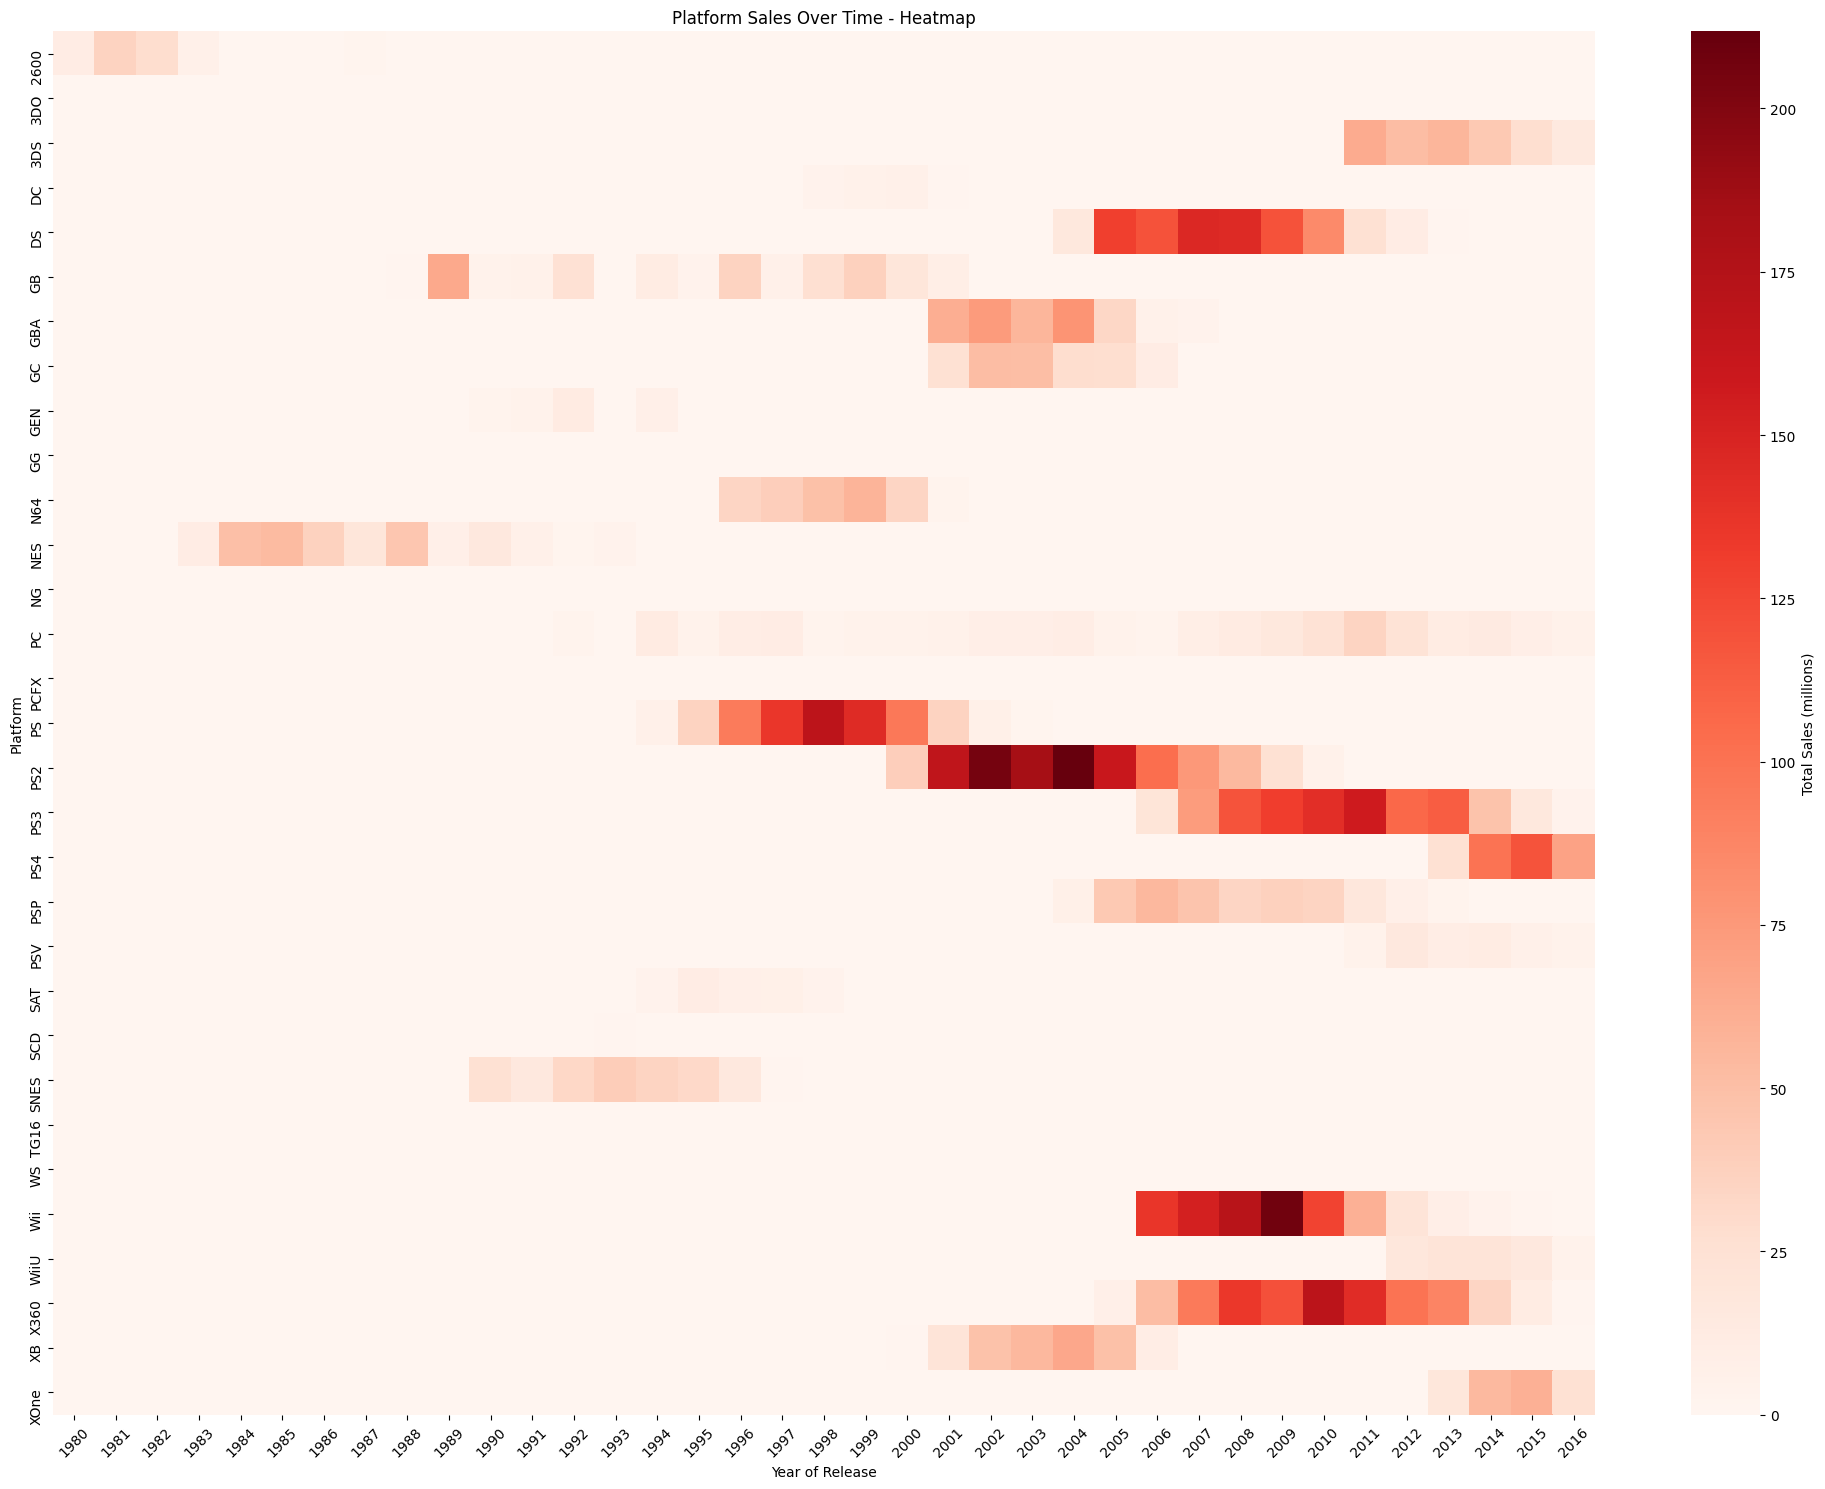

In [18]:
# heatmap of platform sales over time:

# Reset the index to make platform and year regular columns instead of multi-index
sales_df = sales_per_platform_year.reset_index()

# Creating pivot table
pivot_table = sales_df.pivot(values='total_revenue',
                            index='platform',      
                            columns='year_of_release')

# Convert column names (years) to integers for cleaner display (shorter)
pivot_table.columns = pivot_table.columns.astype(int)

# Heatmap details
plt.figure(figsize=(20, 15)) #have to make it big because of sample size
sns.heatmap(pivot_table.fillna(0),
            cmap='Reds',  # tried to choose a visually distinct color, scale starts weak so it's easier to notice change
            cbar_kws={'label': 'Total Sales (millions)'})
plt.title('Platform Sales Over Time - Heatmap')
plt.xlabel('Year of Release')  # Years on x-axis
plt.ylabel('Platform')         # Platforms on y-axis
plt.xticks(rotation=45) #same formatting to make it easier to read
plt.tight_layout()
plt.show()

In [19]:
# Identify platforms with declining sales
# fill series with declining platforms + info
declining_platforms = []
#growing_platforms = []

for platform in pivot_table.index:
    platform_data = pivot_table.loc[platform].dropna()  # Remove NaN years
    
    if len(platform_data) >= 3:  # Need at least 3 years of data
        # Calculate year-over-year changes
        changes = platform_data.diff().dropna()  # diff() gives year-over-year change
        
        # Check if more years show decline than growth
        declining_years = (changes < 0).sum()
        total_years = len(changes)
        
        if declining_years > total_years * 0.6:  # If more than 60% declining years, add to list
       #if declining_years < total_years * 0.4: # If less than 40% declining years, add to growing
           #growing_platforms.append(platform)
            declining_platforms.append(platform)
            print(f"{platform}: {declining_years}/{total_years} years declining") #display the platform as it's added

print(f"\nPlatforms with declining sales: {declining_platforms}") #report the full list

3DS: 4/5 years declining
DS: 7/10 years declining
GC: 5/6 years declining
NG: 2/3 years declining
PS2: 8/11 years declining
PSP: 8/11 years declining
SAT: 4/5 years declining
SNES: 6/9 years declining
Wii: 7/10 years declining
X360: 7/11 years declining

Platforms with declining sales: ['3DS', 'DS', 'GC', 'NG', 'PS2', 'PSP', 'SAT', 'SNES', 'Wii', 'X360']


In [20]:
# identifying how many platforms haven't had any major sales in over a decade
platforms_after_2009 = set(data[data['year_of_release'] > 2006]['platform'].unique()) # identify which platforms have been published recently
all_platforms = set(data['platform'].unique()) #identify all platforms
platforms_no_sales_after_2009 = list(all_platforms - platforms_after_2009) #identify which platforms haven't been published recently with old = total-recent
print(platforms_no_sales_after_2009)

['GEN', 'SNES', 'N64', 'TG16', '3DO', 'SAT', 'NES', '2600', 'PCFX', 'SCD', 'GB', 'WS', 'NG', 'GG', 'PS']


In [21]:
# identifying the average lifespan of a platform
def platform_lifespan():
    years = data.groupby('platform')['year_of_release'].agg(['min', 'max']).dropna() #take platforms based on year of release, find the min/max
    years['lifespan'] = years['max'] - years['min'] + 1 # take the lifespan as the range (max-min), factor in a full year passing
    return years['lifespan'].mean()

print(f"Average platform lifespan: {platform_lifespan():.1f} years")

Average platform lifespan: 8.6 years


### Platform Trend Observations

- Platform trajectories differ significantly; PS4 and XOne show stronger late-period momentum while several legacy platforms contract.
- Platforms with no meaningful post-2006 presence were treated as effectively retired in this market view.
- The typical platform lifecycle is about 8.6 years, which supports using a recent multi-year slice for forecasting work.

### Determining the Relevant Forecasting Window

The next step defines the year range used for 2017 forecasting so it reflects current market dynamics without sacrificing sample size.

In [ ]:
# Evaluate candidate cutoff years for a forecasting window

# Inspect how many years of observations each platform has
platform_years = pivot_table.apply(lambda row: row.dropna().count(), axis=1).sort_values(ascending=False)
print("Years of data per platform:")
print(platform_years)

# Summarize platform coverage distribution
print(f"\nPlatform data distribution:")
print(f"Platforms with 1-3 years: {(platform_years <= 3).sum()}")
print(f"Platforms with 4-6 years: {((platform_years > 3) & (platform_years <= 6)).sum()}")
print(f"Platforms with 7+ years: {(platform_years > 6).sum()}")
# Compare sample size and average sales for several cutoffs
for cutoff_year in [2010, 2011, 2012, 2013]:
    recent_data = data[data['year_of_release'] >= cutoff_year]
    print(f"From {cutoff_year}: {len(recent_data)} games, avg sales: {recent_data['total_sales'].mean():.2f}")

relevant_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016]
data_relevant = data[data['year_of_release'].isin(relevant_years)]
data_relevant.info()

Years of data per platform:
platform
PC      26
GB      13
NES     12
X360    12
PSP     12
PS2     12
Wii     11
DS      11
PS3     11
2600    10
SNES    10
PS      10
XB       9
GBA      8
DC       7
GC       7
N64      7
SAT      6
3DS      6
PSV      6
WiiU     5
GEN      5
NG       4
PS4      4
XOne     4
WS       3
SCD      2
3DO      2
TG16     1
GG       1
PCFX     1
dtype: int64

Platform data distribution:
Platforms with 1-3 years: 6
Platforms with 4-6 years: 8
Platforms with 7+ years: 17
From 2010: 5277 games, avg sales: 0.48
From 2011: 4022 games, avg sales: 0.49
From 2012: 2886 games, avg sales: 0.50
From 2013: 2233 games, avg sales: 0.49
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5277 entries, 14 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             5277 non-null   object 
 1   platform         5277 non-null   object 
 2   year_of_release  5277 non-null   float64
 

### Forecast Window Selection Rationale

A 2010-2016 window was selected to balance recency with analytical coverage. Shorter windows (2-3 years) are more reactive but reduce sample depth, while this 7-year span better captures platform cycles, stable genre tendencies, and regional behavior patterns relevant to 2017 planning.

### Platform Performance in the Selected Period

Using the 2010-2016 slice, platform-level revenue and growth behavior are compared to identify strong candidates for 2017 targeting.

In [23]:
# grouping platform and year to see how much each platform makes per year
sales_per_platform_recent = data_relevant.groupby(['platform', 'year_of_release'])['total_sales'].sum().to_frame('total_revenue')
print(sales_per_platform_recent)

                          total_revenue
platform year_of_release               
3DS      2011.0                   63.20
         2012.0                   51.36
         2013.0                   56.57
         2014.0                   43.76
         2015.0                   27.78
...                                 ...
X360     2016.0                    1.52
XOne     2013.0                   18.96
         2014.0                   54.07
         2015.0                   60.14
         2016.0                   26.15

[65 rows x 1 columns]


In [24]:
# Sort platforms by total sales
sales_df = sales_per_platform_recent.reset_index()

# initializing the pivot table
pivot_table = sales_df.pivot(values='total_revenue',
                            index='platform',      
                            columns='year_of_release')

pivot_table.columns = pivot_table.columns.astype(int)# Convert column names (years) to integers for cleaner display
pivot_table['total_revenue'] = pivot_table.sum(axis='columns') # adding a revenue column back after resetting index
sales_df = pivot_table.reindex(pivot_table['total_revenue'].sort_values(ascending=False).index) # re-sorting by total sales for graph

print(sales_df)

year_of_release    2010    2011    2012    2013    2014    2015   2016  \
platform                                                                 
PS3              142.17  156.78  107.36  113.25   47.76   16.82   3.60   
X360             170.03  143.84   99.74   88.58   34.74   11.96   1.52   
PS4                 NaN     NaN     NaN   25.99  100.00  118.90  69.25   
3DS                 NaN   63.20   51.36   56.57   43.76   27.78  15.14   
Wii              127.95   59.65   21.71    8.59    3.75    1.14   0.18   
XOne                NaN     NaN     NaN   18.96   54.07   60.14  26.15   
DS                85.02   26.18   11.01    1.54     NaN     NaN    NaN   
PC                24.28   35.03   23.22   12.38   13.28    8.52   5.25   
WiiU                NaN     NaN   17.56   21.65   22.03   16.35   4.60   
PSP               35.04   17.82    7.69    3.14    0.24    0.12    NaN   
PSV                 NaN    4.63   16.19   10.59   11.90    6.25   4.25   
PS2                5.64    0.45     Na

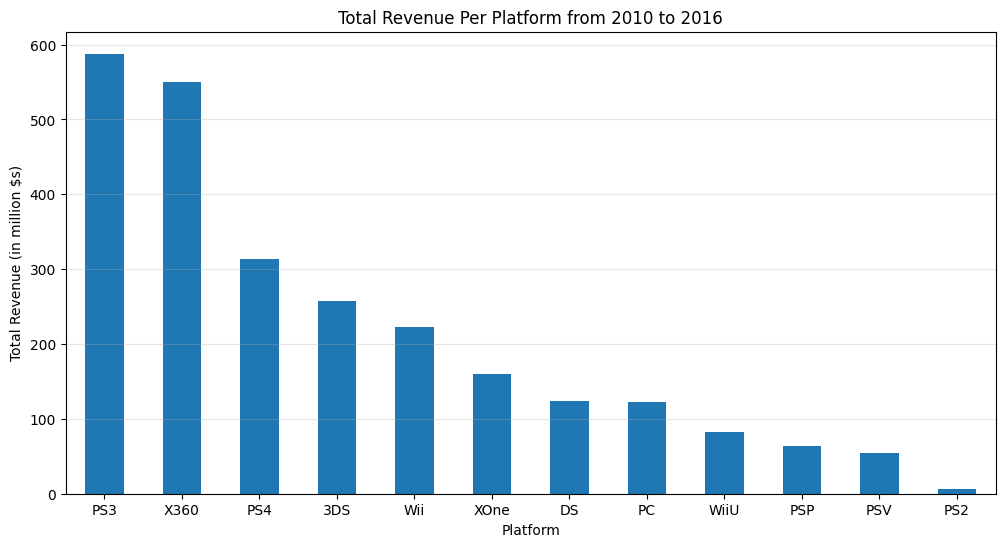

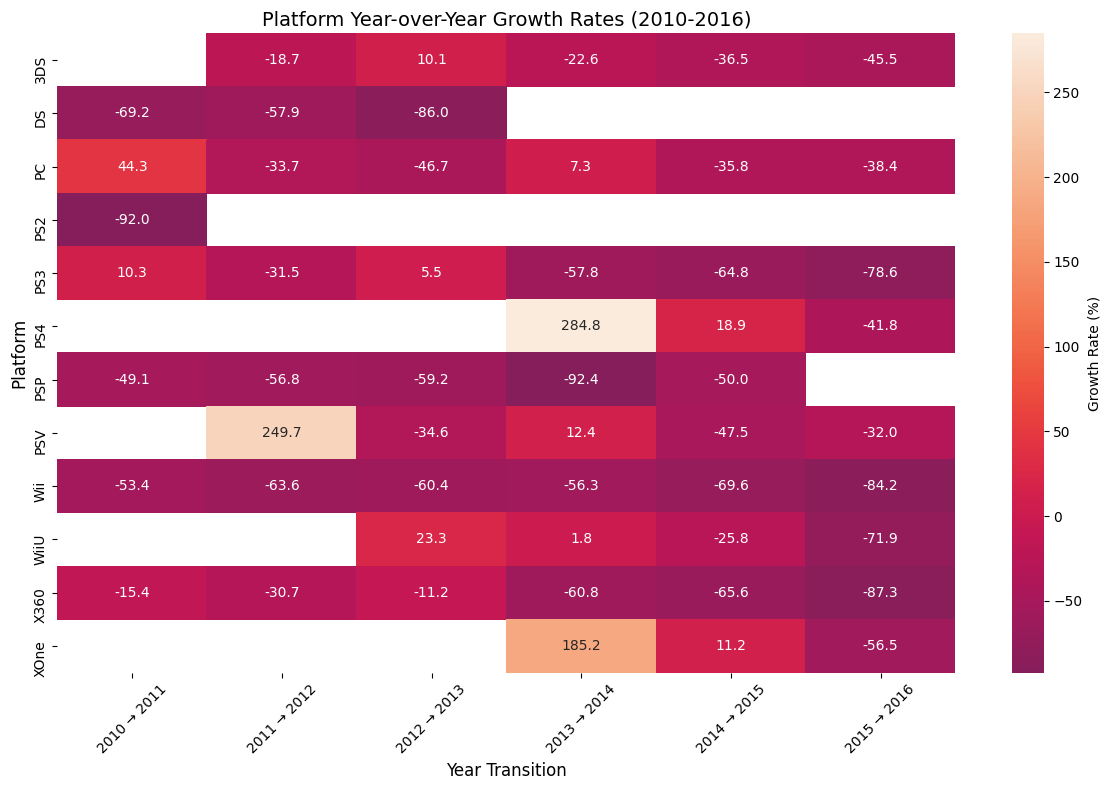

In [25]:
# bar graph to visualize revenue
sales_graph = pd.DataFrame({'Platform': sales_df.index, 'Total Revenue': sales_df['total_revenue']})
sales_graph.plot(x='Platform', y='Total Revenue', kind='bar', figsize=(12, 6), 
                  title="Total Revenue Per Platform from 2010 to 2016", ylabel='Total Revenue (in million $s)', 
                  xlabel='Platform', legend=False)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

# Calculating year-over-year growth for each platform:
growth_data = []
for platform in pivot_table.index: # for each platform:
    platform_data = pivot_table.loc[platform].dropna()  # Remove NaN years from the platform data
    if len(platform_data) >= 2:  # Need at least 2 years for growth calculation
        # calculations
        year_columns = [col for col in platform_data.index if col != 'total_revenue'] # find all the years
        platform_years_only = platform_data[year_columns] # isolate the platform years 
        growth_rates = platform_years_only.pct_change().dropna() * 100 # represent the growth rate as a percent, omitting null
        
        for year, growth in growth_rates.items():  # Now year is defined here
            growth_data.append({
                'platform': platform,
                'year_transition': f"{int(year-1)} → {int(year)}",
                'growth_rate': growth
            })

# Create DataFrame for easier analysis
growth_df = pd.DataFrame(growth_data)
growth_pivot = growth_df.pivot(index='platform', 
                              columns='year_transition', 
                              values='growth_rate')

plt.figure(figsize=(12, 8))
sns.heatmap(growth_pivot,
            annot=True,
            fmt='.1f',
            cmap='rocket',  # Seaborn rocket colormap, hard to find a preset, would make a custom colormap if needed
            center=0,
            cbar_kws={'label': 'Growth Rate (%)'})
plt.title('Platform Year-over-Year Growth Rates (2010-2016)', fontsize=14)
plt.xlabel('Year Transition', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Distribution Analysis

This section evaluates how individual game sales are distributed across platforms, including skewness and outlier behavior.

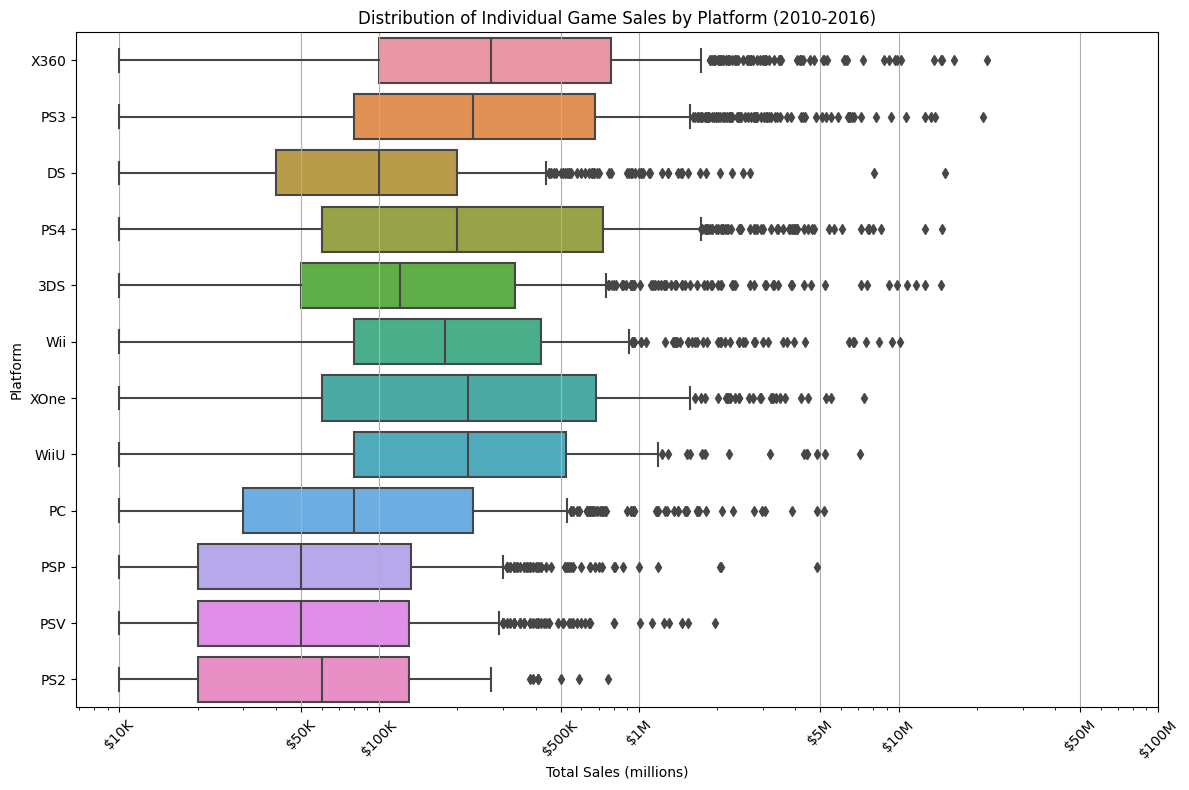

In [26]:
# Create box plot of sales by platform
# Use the original data_relevant for individual game sales distribution

plt.figure(figsize=(12, 8))
# Graphing horizontally due to outliers stretching the graph, and logarithmic stretching to make it easier to parse
sns.boxplot(data=data_relevant, x='total_sales', y='platform')
plt.xscale('log')
# Add more tick marks for better readability
tick_values = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
tick_labels = ['$10K', '$50K', '$100K', '$500K', '$1M', '$5M', '$10M', '$50M', '$100M'] #add condensed labeling
plt.xticks(tick_values, tick_labels)
plt.grid(axis='x')
plt.title('Distribution of Individual Game Sales by Platform (2010-2016)')
plt.ylabel('Platform')
plt.xlabel('Total Sales (millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Calculate detailed statistics for each platform
platform_stats = data_relevant.groupby('platform')['total_sales']
platform_stats.describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,512.0,0.503535,1.441271,0.01,0.05,0.12,0.3325,14.60
DS,507.0,0.244083,0.815643,0.01,0.04,0.10,0.2000,15.13
PC,479.0,0.254614,0.530874,0.01,0.03,0.08,0.2300,5.14
PS2,45.0,0.135333,0.180638,0.01,0.02,0.06,0.1300,0.76
PS3,889.0,0.661125,1.459651,0.01,0.08,0.23,0.6800,21.05
PS4,392.0,0.801378,1.609456,0.01,0.06,0.20,0.7300,14.63
PSP,500.0,0.128100,0.288250,0.01,0.02,0.05,0.1325,4.87
PSV,429.0,0.125431,0.212341,0.01,0.02,0.05,0.1300,1.96
Wii,450.0,0.495489,1.118375,0.01,0.08,0.18,0.4200,10.12


### Review Score Impact Analysis

The relationship between review scores and sales is examined on a popular platform using scatter plots and correlation coefficients.

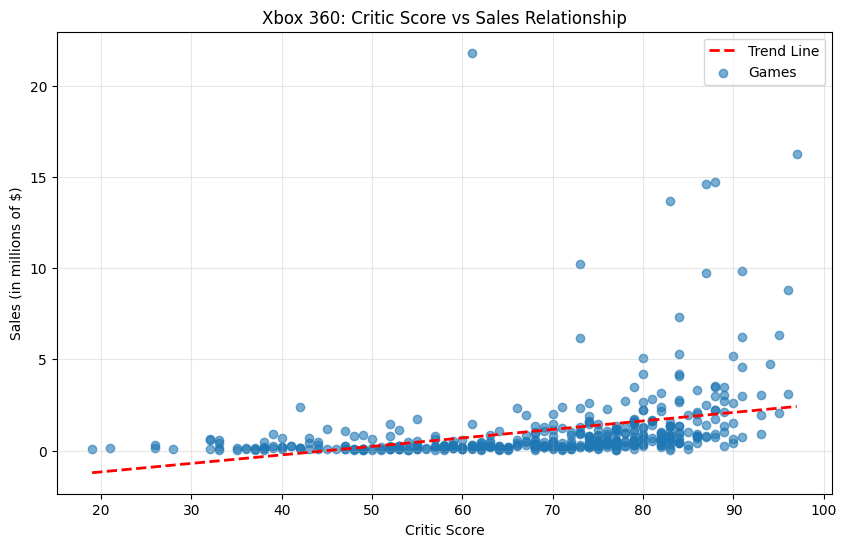

In [28]:
# Create scatter plots for both critic and user scores for XBox 360
# Critic Scores scatter plot:
# Group xbox360 games, taking critic score + user score + total sales
critic_data = data_relevant[data_relevant['platform'] == 'X360'][['critic_score', 'total_sales']].dropna()  #omit null critic scores

plt.figure(figsize=(10, 6))
# Calculate trendline
x = critic_data['critic_score']
y = critic_data['total_sales']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y, alpha=0.6, label='Games') # Plot scatter points
x_sorted = np.sort(x) # sort values to make a line
plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label='Trend Line') # plot trendline

plt.xlabel('Critic Score')
plt.ylabel('Sales (in millions of $)')
plt.title('Xbox 360: Critic Score vs Sales Relationship')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

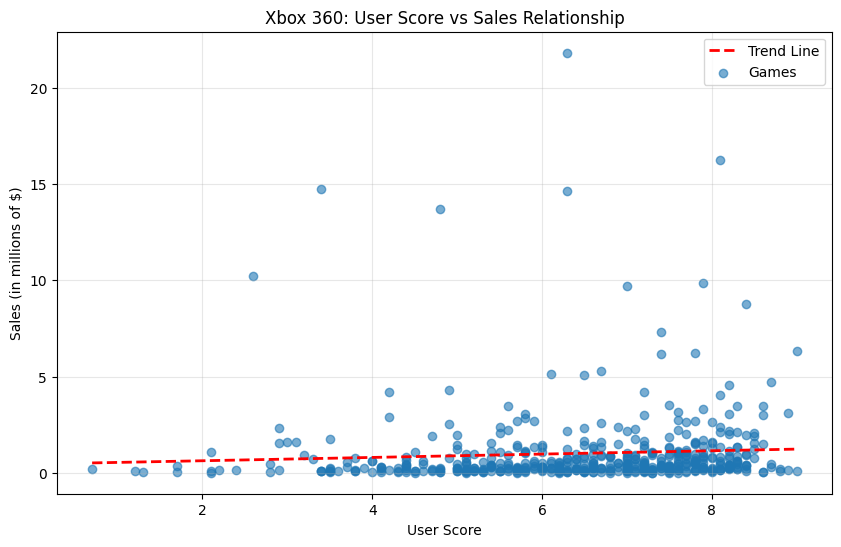

In [29]:
# User Scores scatter plot
user_data = data_relevant[data_relevant['platform'] == 'X360'][['user_score', 'total_sales']].dropna()
plt.figure(figsize=(10, 6))
# Calculate trendline
x = user_data['user_score'] #just need x, keep y from last graph
y = user_data['total_sales']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# populate graph
plt.scatter(x, y, alpha=0.6, label='Games')
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label='Trend Line') #trend line

plt.xlabel('User Score')
plt.ylabel('Sales (in millions of $)')
plt.title('Xbox 360: User Score vs Sales Relationship')  # This title is correct
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Calculate correlations
print(f"Correlation between critic score and sales: {critic_data['critic_score'].corr(critic_data['total_sales']):.3f}")
print(f"Correlation between user score and sales: {user_data['user_score'].corr(user_data['total_sales']):.3f}")

Correlation between critic score and sales: 0.340
Correlation between user score and sales: 0.066


### Cross-Platform Comparison

Sales performance is compared for titles released on multiple platforms to evaluate where cross-platform launches perform best.

In [31]:
# Find games released on multiple platforms
multi_plat = data_relevant.groupby('name').filter(lambda x: x['platform'].size > 1).sort_values(by=['name'])
unique_name = multi_plat['name'].unique() # check for unique game names
print(unique_name.size)

1015


Average sales performance for cross-platform games by platform:
platform
PS4     0.880943
X360    0.802706
PS3     0.735842
XOne    0.603080
Wii     0.524153
3DS     0.318828
WiiU    0.302424
DS      0.278102
PC      0.267305
PS2     0.207778
PSP     0.187411
PSV     0.147165
Name: total_sales, dtype: float64


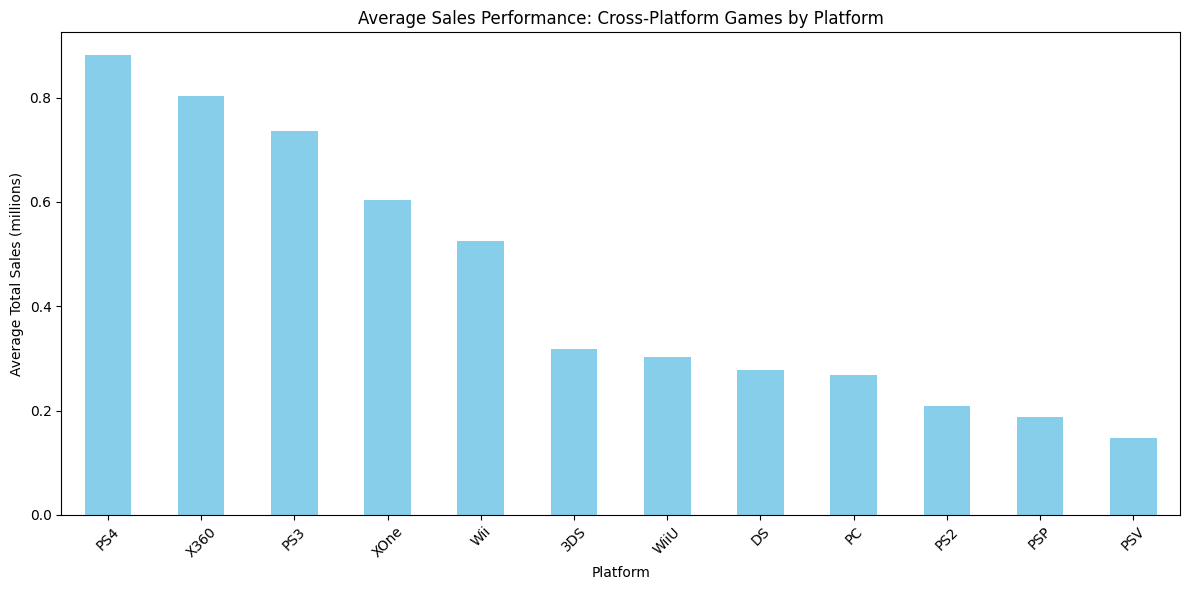

<Figure size 1200x800 with 0 Axes>

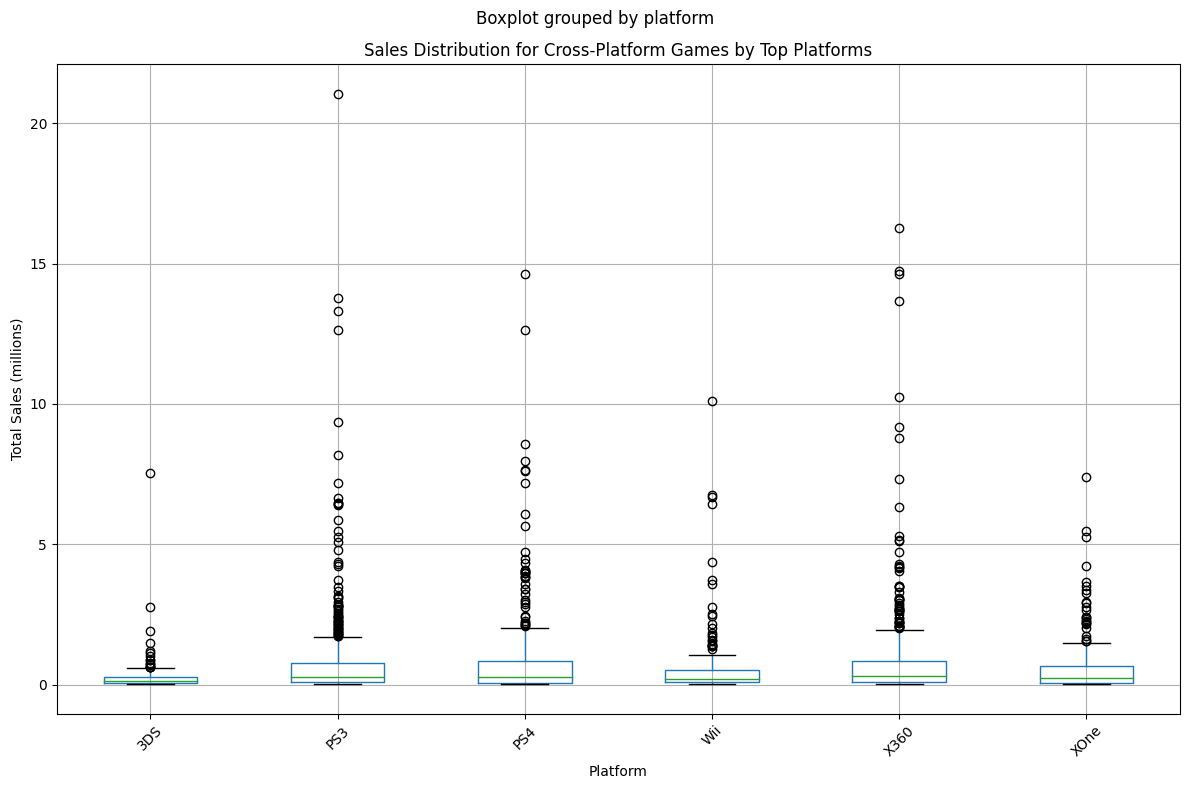

In [ ]:
# Average sales per platform for cross-platform titles
def analyze_cross_platform_performance(data):
    # Keep only games released on more than one platform
    multi_platform_games = data.groupby('name').filter(lambda x: x['platform'].nunique() > 1)
    
    # Compute mean sales by platform
    avg_sales_by_platform = multi_platform_games.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
    
    return avg_sales_by_platform, multi_platform_games
# Compare performance of a single title across platforms
def compare_game_across_platforms(game_name, data):
    game_data = data[data['name'] == game_name]
    return game_data[['platform', 'total_sales']].sort_values('total_sales', ascending=False)
    
# Build the multi-platform subset
multi_platform_games = data_relevant.groupby('name').filter(lambda x: x['platform'].nunique() > 1)

# Calculate platform-level averages on the subset
avg_sales_by_platform = multi_platform_games.groupby('platform')['total_sales'].mean().sort_values(ascending=False)

print("Average sales performance for cross-platform games by platform:")
print(avg_sales_by_platform)

# Bar chart of average sales by platform
plt.figure(figsize=(12, 6))
avg_sales_by_platform.plot(kind='bar', color='skyblue')
plt.title('Average Sales Performance: Cross-Platform Games by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Total Sales (millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Box plot showing sales distribution for top platforms
top_platforms = avg_sales_by_platform.head(6).index  # Top 6 platforms
platform_data = multi_platform_games[multi_platform_games['platform'].isin(top_platforms)]

plt.figure(figsize=(12, 8))
platform_data.boxplot(column='total_sales', by='platform', figsize=(12, 8))
plt.title('Sales Distribution for Cross-Platform Games by Top Platforms')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Genre Analysis

Genre-level totals, rankings over time, and per-title averages are evaluated to identify categories with both scale and efficiency.

In [33]:
# Analyze genre performance
genre_list = data_relevant['genre'].unique() #find all unique genres
genre_sales = []
genre_listed = []
for genre in genre_list: #for each genre
    genre_sales.append(data_relevant.loc[data_relevant['genre'] == genre, 'total_sales'].sum()) #find all matching genres, add to 
    genre_listed.append(genre)

# Sort genres by total sales
genre_data = pd.Series(data= genre_sales, index = genre_listed).sort_values(ascending=False) #combine both series to read
print(genre_data)
genre_data.sum()

Action          673.09
Shooter         479.74
Sports          328.39
Role-Playing    315.28
Misc            234.56
Racing          122.68
Platform        119.72
Fighting         81.59
Simulation       71.75
Adventure        61.00
Strategy         35.84
Puzzle           20.60
dtype: float64


2544.2400000000002

In [34]:
# Calculate market share for each genre
market_share = (genre_data / genre_data.sum())*100 # what percent each game makes up of total sales
print(market_share)

Action          26.455444
Shooter         18.855926
Sports          12.907194
Role-Playing    12.391913
Misc             9.219256
Racing           4.821872
Platform         4.705531
Fighting         3.206852
Simulation       2.820096
Adventure        2.397573
Strategy         1.408672
Puzzle           0.809672
dtype: float64


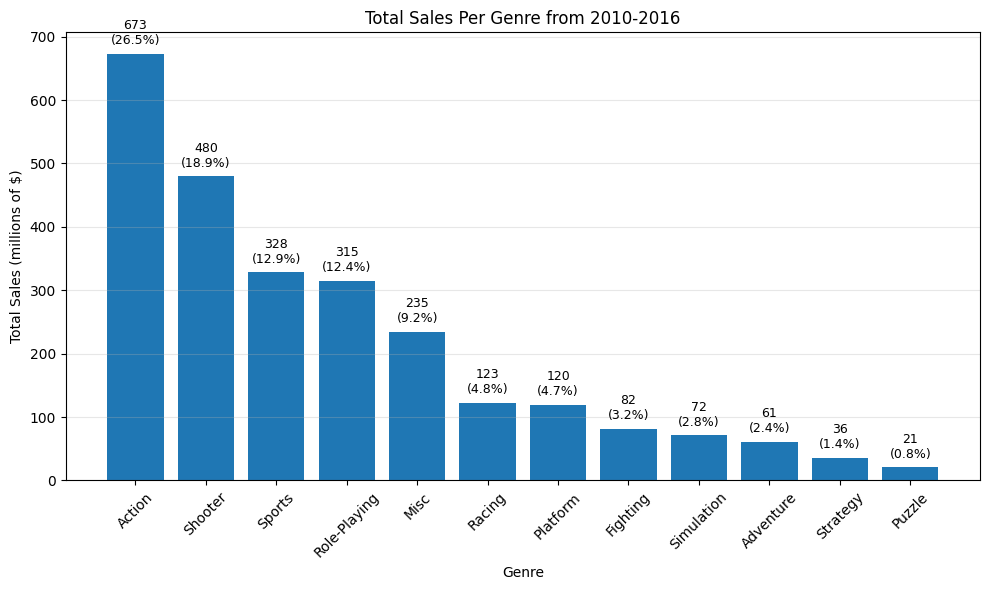

In [35]:
# Visualize genre distribution
plt.figure(figsize=(10,6))
bars = plt.bar(genre_data.index, genre_data.values)
plt.title("Total Sales Per Genre from 2010-2016")
plt.ylabel('Total Sales (millions of $)')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add labels with both sales values and percentages
for i, (sales, percent) in enumerate(zip(genre_data.values, market_share.values)):
    plt.text(i, sales + 10, f'{sales:,.0f}\n({percent:.1f}%)', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

year_of_release  2010.0  2011.0  2012.0  2013.0  2014.0  2015.0  2016.0
genre                                                                  
Action              1.0     1.0     1.0     1.0     1.0     1.0     2.0
Adventure           9.0     9.0    10.0    11.0    10.0     6.0     6.0
Fighting           10.0     8.0     9.0     9.0     7.0     8.0     5.0
Misc                2.0     4.0     5.0     5.0     5.0     5.0     9.0
Platform            7.0     7.0     6.0     6.0     8.0     9.0     7.0
Puzzle             12.0    12.0    12.0    12.0    11.0    12.0    12.0
Racing              6.0     6.0     7.0     7.0     6.0     7.0     8.0
Role-Playing        5.0     5.0     3.0     3.0     3.0     4.0     4.0
Shooter             4.0     2.0     2.0     2.0     2.0     2.0     1.0
Simulation          8.0    10.0     8.0     8.0     9.0    10.0    10.0
Sports              3.0     3.0     4.0     4.0     4.0     3.0     3.0
Strategy           11.0    11.0    11.0    10.0    12.0    11.0 

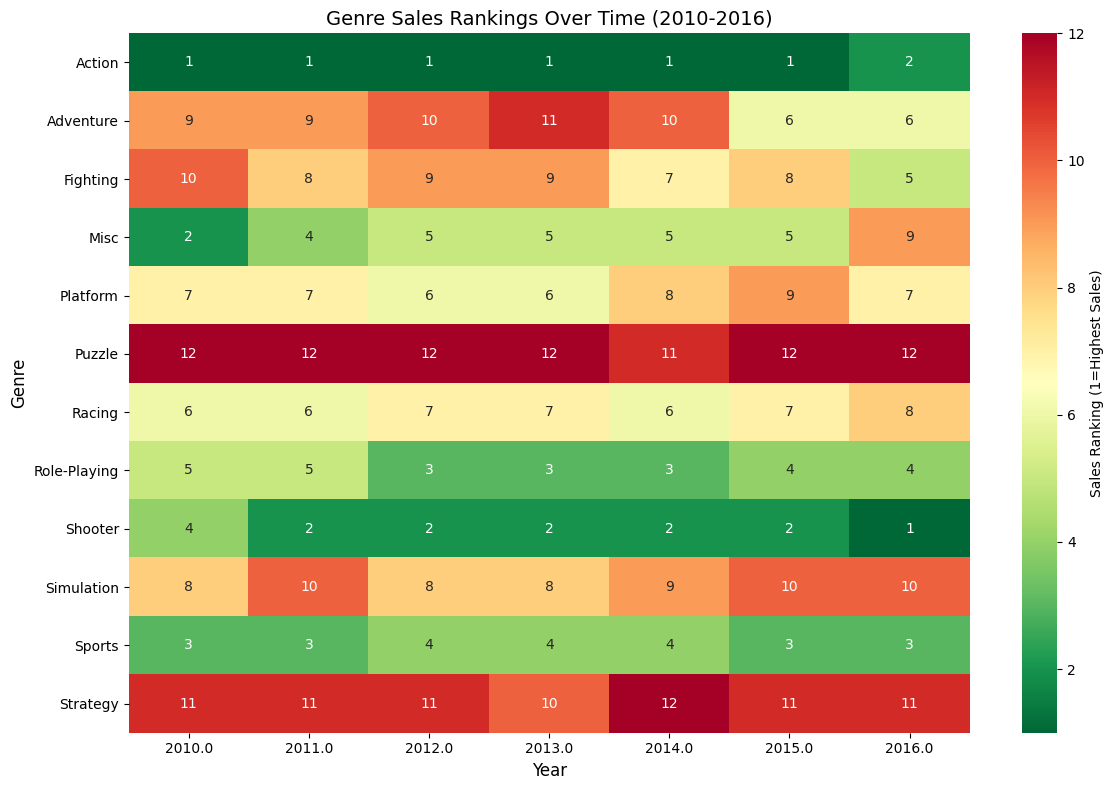

In [36]:
# Group by genre and year to get total sales
genre_year_sales = data_relevant.groupby(['genre', 'year_of_release'])['total_sales'].sum().reset_index()
# Create pivot table from your grouped data
genre_pivot = genre_year_sales.pivot(index='genre', columns='year_of_release', values='total_sales')
# Convert sales to rankings (1 = highest sales, 2 = second highest, etc.)
genre_rankings = genre_pivot.rank(method='min', ascending=False)
print(genre_rankings)
# Create the genre rankings heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(genre_rankings, 
            annot=True, 
            fmt='.0f',
            cmap='RdYlGn_r',  # Red-Yellow-Green reversed (red=high rank/low sales, green=low rank/high sales)
            cbar_kws={'label': 'Sales Ranking (1=Highest Sales)'})

plt.title('Genre Sales Rankings Over Time (2010-2016)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

Genre Performance Analysis:
              total_sales  avg_sales  game_count
genre                                           
Action             673.09       0.45        1495
Shooter            479.74       1.17         410
Sports             328.39       0.57         575
Role-Playing       315.28       0.56         568
Misc               234.56       0.41         576
Racing             122.68       0.52         237
Platform           119.72       0.78         153
Fighting            81.59       0.41         199
Simulation          71.75       0.33         217
Adventure           61.00       0.11         563
Strategy            35.84       0.21         170
Puzzle              20.60       0.18         114


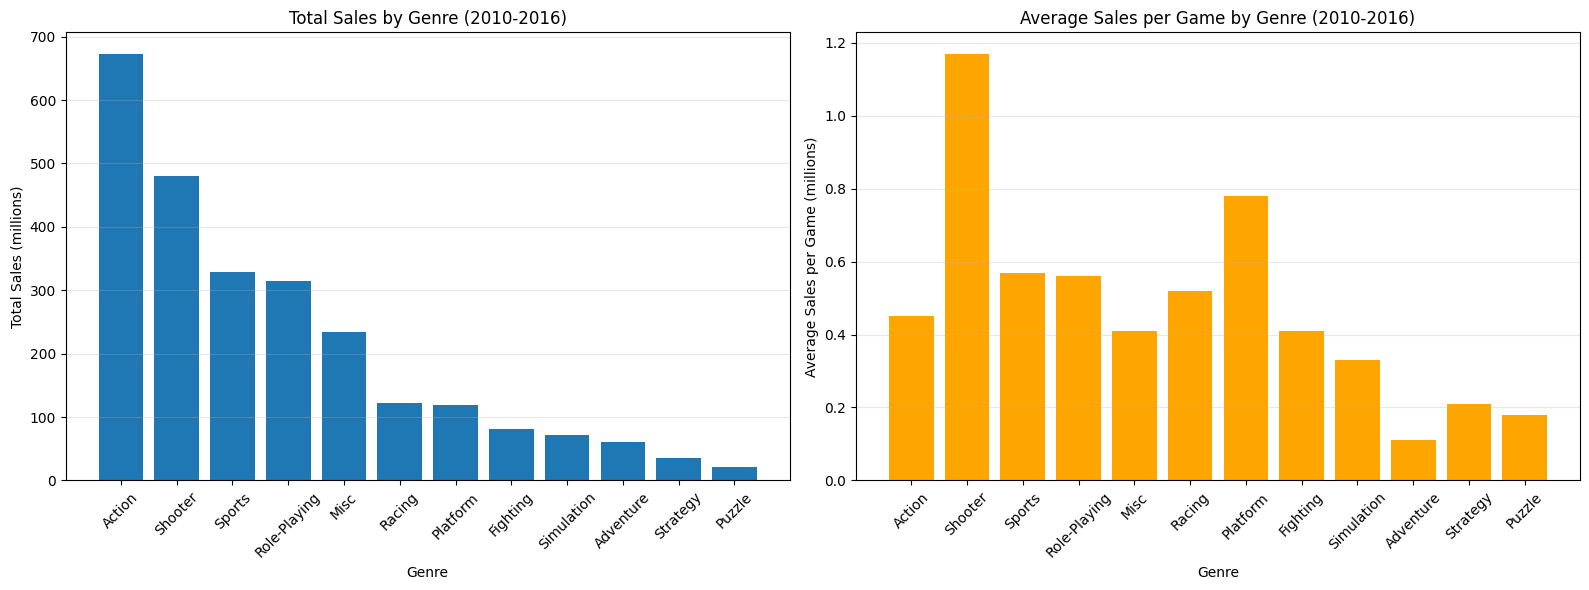


Key Insights:
Genre with highest total sales: Action ($673M total)
Genre with highest average sales: Shooter ($1.17M average)
Most prolific genre: Action (1495 games)


In [37]:
# Calculate both total and average sales by genre
genre_analysis = data_relevant.groupby('genre').agg({
    'total_sales': ['sum', 'mean', 'count']
}).round(2)

# Flatten column names for easier access
genre_analysis.columns = ['total_sales', 'avg_sales', 'game_count']

# Sort by total sales (descending) to match your existing analysis
genre_analysis = genre_analysis.sort_values('total_sales', ascending=False)

print("Genre Performance Analysis:")
print(genre_analysis)

# Create a comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total sales bar chart (your existing analysis)
ax1.bar(genre_analysis.index, genre_analysis['total_sales'])
ax1.set_title('Total Sales by Genre (2010-2016)')
ax1.set_ylabel('Total Sales (millions)')
ax1.set_xlabel('Genre')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Average sales bar chart (new analysis)
ax2.bar(genre_analysis.index, genre_analysis['avg_sales'], color='orange')
ax2.set_title('Average Sales per Game by Genre (2010-2016)')
ax2.set_ylabel('Average Sales per Game (millions)')
ax2.set_xlabel('Genre')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display insights
print("\nKey Insights:")
print(f"Genre with highest total sales: {genre_analysis.index[0]} (${genre_analysis.iloc[0]['total_sales']:.0f}M total)")
print(f"Genre with highest average sales: {genre_analysis.sort_values('avg_sales', ascending=False).index[0]} (${genre_analysis.sort_values('avg_sales', ascending=False).iloc[0]['avg_sales']:.2f}M average)")
print(f"Most prolific genre: {genre_analysis.sort_values('game_count', ascending=False).index[0]} ({genre_analysis.sort_values('game_count', ascending=False).iloc[0]['game_count']:.0f} games)")

### Genre Analysis Highlights

- Action and Shooter genres consistently lead overall sales in the selected period.
- Adventure titles show recent improvement, although this may be driven by a small number of breakout releases.
- Average sales by genre confirm that total volume and per-game performance can tell different stories, which is important for campaign planning.

## Regional Market Analysis and User Profiles

This section compares North America, Europe, and Japan across platform preference, genre performance, and ESRB rating patterns.

### Regional Platform Analysis

In [38]:
# Function to analyze platform performance by region
# want the top 5 platforms per region
# it'll be overall platform performance but split into 3 regions, each row has 3 region values
def analyze_platform_region(region, top=5):
    region_compare = region + "_sales"
    return data_relevant.groupby(['platform'])[region_compare].sum().sort_values(ascending=False).head(top)

In [39]:
# Analyze each region
eu_data = analyze_platform_region('eu')
na_data = analyze_platform_region('na')
jp_data = analyze_platform_region('jp')
print(eu_data)
print(na_data)
print(jp_data)

platform
PS3     213.60
X360    163.41
PS4     141.09
PC       68.82
Wii      65.91
Name: eu_sales, dtype: float64
platform
X360    334.18
PS3     229.25
Wii     121.20
PS4     108.74
XOne     93.12
Name: na_sales, dtype: float64
platform
3DS    100.62
PS3     59.26
PSP     42.20
DS      27.90
PSV     21.84
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

A unified comparison table and chart are used below to contrast platform strength across regions.

In [40]:
# Create a comparative platform analysis

def create_platform_comparison():
    # Create a DataFrame for comparison
    comparison_df = pd.DataFrame({
        'North America': na_data,
        'Europe': eu_data,
        'Japan': jp_data
    }).fillna(0)

    return comparison_df

# Get the comparison data
print("Platform Sales Comparison (Top 5 per Region):")
print(create_platform_comparison())

Platform Sales Comparison (Top 5 per Region):
          North America  Europe   Japan
platform                               
3DS                0.00    0.00  100.62
DS                 0.00    0.00   27.90
PC                 0.00   68.82    0.00
PS3              229.25  213.60   59.26
PS4              108.74  141.09    0.00
PSP                0.00    0.00   42.20
PSV                0.00    0.00   21.84
Wii              121.20   65.91    0.00
X360             334.18  163.41    0.00
XOne              93.12    0.00    0.00


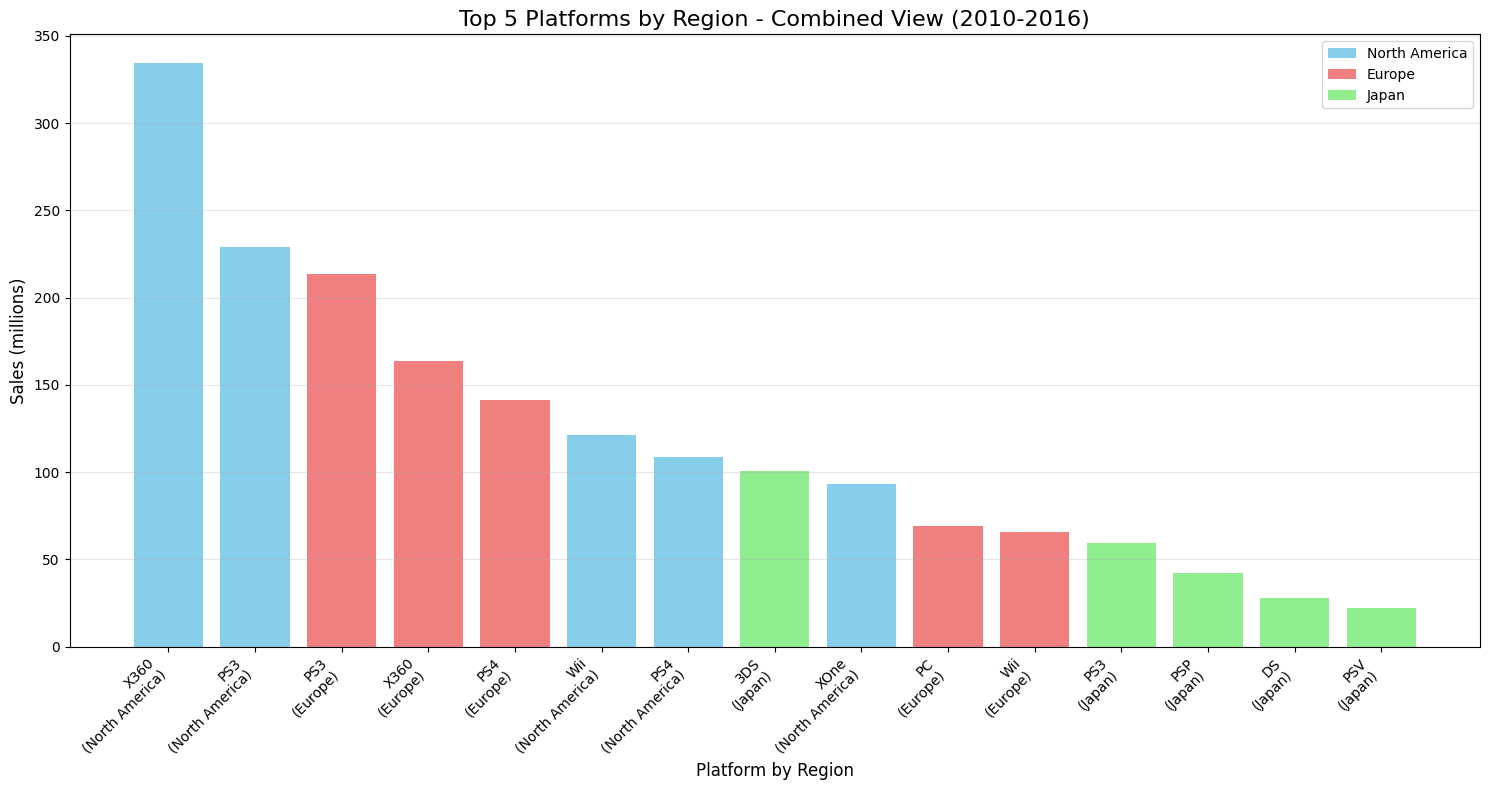

Combined Platform Sales Data (sorted by sales):
   Platform   Sales         Region
0      X360  334.18  North America
1       PS3  229.25  North America
5       PS3  213.60         Europe
6      X360  163.41         Europe
7       PS4  141.09         Europe
2       Wii  121.20  North America
3       PS4  108.74  North America
10      3DS  100.62          Japan
4      XOne   93.12  North America
8        PC   68.82         Europe
9       Wii   65.91         Europe
11      PS3   59.26          Japan
12      PSP   42.20          Japan
13       DS   27.90          Japan
14      PSV   21.84          Japan


In [41]:
# Visualize cross-regional comparison for top platforms
# Create side-by-side bar chart using a combined dataset

combined_data = []
for platform, sales in na_data.items(): # Add North America data
    combined_data.append({'Platform': platform, 'Sales': sales, 'Region': 'North America'})
for platform, sales in eu_data.items(): # Add Europe data  
    combined_data.append({'Platform': platform, 'Sales': sales, 'Region': 'Europe'})
for platform, sales in jp_data.items():# Add Japan data
    combined_data.append({'Platform': platform, 'Sales': sales, 'Region': 'Japan'})
    
# setting up the graph data:
combined_df = pd.DataFrame(combined_data)
combined_df = combined_df.sort_values('Sales', ascending=False)# Sort by sales values (highest to lowest)
plt.figure(figsize=(15, 8)) # visualization
colors = {'North America': 'skyblue', 'Europe': 'lightcoral', 'Japan': 'lightgreen'}

# Create bar chart
bars = plt.bar(range(len(combined_df)), combined_df['Sales'], 
               color=[colors[region] for region in combined_df['Region']])
plt.title('Top 5 Platforms by Region - Combined View (2010-2016)', fontsize=16)
plt.xlabel('Platform by Region', fontsize=12)
plt.ylabel('Sales (millions)', fontsize=12)

# Set x-axis labels
labels = [f"{row['Platform']}\n({row['Region']})" for _, row in combined_df.iterrows()]
plt.xticks(range(len(combined_df)), labels, rotation=45, ha='right')
# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[region], label=region) for region in colors.keys()]
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# Print the data for reference
print("Combined Platform Sales Data (sorted by sales):")
print(combined_df)

### Regional Genre Analysis

Genre demand is compared by region to identify where category preferences converge or diverge.

In [42]:
# Function to analyze genre performance by region
def analyze_genre_region(region, top=5):
    region_compare = region + "_sales"
    return data_relevant.groupby(['genre'])[region_compare].sum().sort_values(ascending=False).head(top)

na_genre = analyze_genre_region('na')
eu_genre = analyze_genre_region('eu')
jp_genre = analyze_genre_region('jp')
print(na_genre, "\n", eu_genre, "\n", jp_genre)

genre
Action          290.64
Shooter         237.47
Sports          156.81
Misc            123.80
Role-Playing    112.05
Name: na_sales, dtype: float64 
 genre
Action          233.63
Shooter         171.45
Sports          116.84
Role-Playing     75.48
Misc             66.09
Name: eu_sales, dtype: float64 
 genre
Role-Playing    103.54
Action           72.20
Misc             24.29
Platform         15.81
Adventure        15.67
Name: jp_sales, dtype: float64


### Cross-Regional Genre Comparison

The comparison below highlights which genres dominate by region and where preferences materially differ.

Genre Sales Comparison (Top 5 per Region):
              North America  Europe   Japan
genre                                      
Action               290.64  233.63   72.20
Adventure              0.00    0.00   15.67
Misc                 123.80   66.09   24.29
Platform               0.00    0.00   15.81
Role-Playing         112.05   75.48  103.54
Shooter              237.47  171.45    0.00
Sports               156.81  116.84    0.00


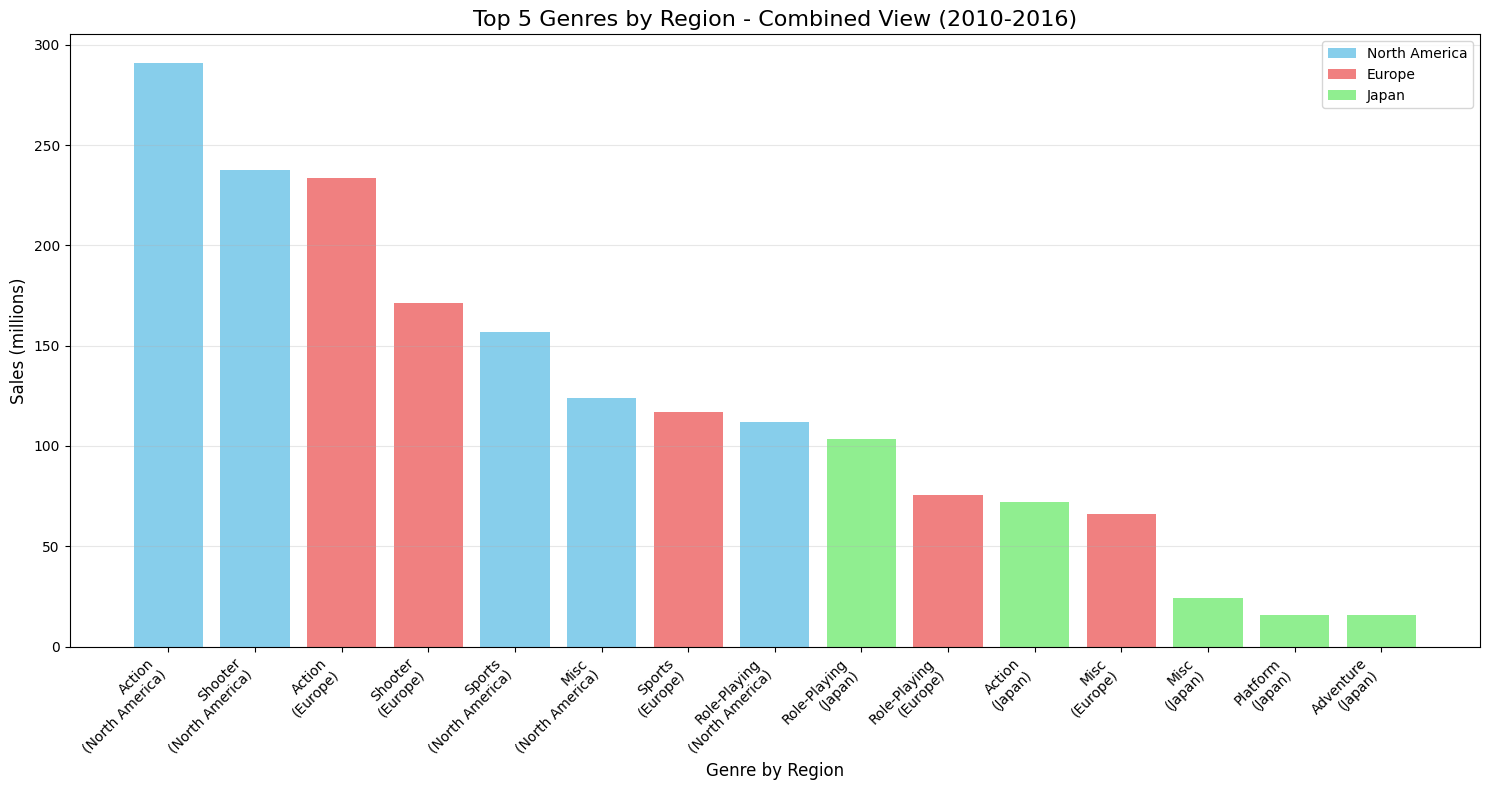

Combined Genre Sales Data (sorted by sales):
           Genre   Sales         Region
0         Action  290.64  North America
1        Shooter  237.47  North America
5         Action  233.63         Europe
6        Shooter  171.45         Europe
2         Sports  156.81  North America
3           Misc  123.80  North America
7         Sports  116.84         Europe
4   Role-Playing  112.05  North America
10  Role-Playing  103.54          Japan
8   Role-Playing   75.48         Europe
11        Action   72.20          Japan
9           Misc   66.09         Europe
12          Misc   24.29          Japan
13      Platform   15.81          Japan
14     Adventure   15.67          Japan


In [43]:
# Create a comparative genre analysis
def create_genre_comparison():
    comparison_df = pd.DataFrame({
        'North America': na_genre,
        'Europe': eu_genre,
        'Japan': jp_genre
    }).fillna(0)
    return comparison_df
    
print("Genre Sales Comparison (Top 5 per Region):") #comparison data
print(create_genre_comparison())

combined_data = []
for genre, sales in na_genre.items():# Add North America data
    combined_data.append({'Genre': genre, 'Sales': sales, 'Region': 'North America'})
for genre, sales in eu_genre.items():# Add Europe data
    combined_data.append({'Genre': genre, 'Sales': sales, 'Region': 'Europe'})
for genre, sales in jp_genre.items():# Add Japan data
    combined_data.append({'Genre': genre, 'Sales': sales, 'Region': 'Japan'})

combined_df = pd.DataFrame(combined_data)
combined_df = combined_df.sort_values('Sales', ascending=False) # Sort by sales values (highest to lowest)
plt.figure(figsize=(15, 8)) # visualization
colors = {'North America': 'skyblue', 'Europe': 'lightcoral', 'Japan': 'lightgreen'}
# Create bar chart
bars = plt.bar(range(len(combined_df)), combined_df['Sales'], 
               color=[colors[region] for region in combined_df['Region']])
plt.title('Top 5 Genres by Region - Combined View (2010-2016)', fontsize=16)
plt.xlabel('Genre by Region', fontsize=12)
plt.ylabel('Sales (millions)', fontsize=12)
# x-axis labels
labels = [f"{row['Genre']}\n({row['Region']})" for _, row in combined_df.iterrows()]
plt.xticks(range(len(combined_df)), labels, rotation=45, ha='right')
# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[region], label=region) for region in colors.keys()]
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the data for reference
print("Combined Genre Sales Data (sorted by sales):")
print(combined_df)

### ESRB Rating Impact Analysis

The final regional comparison focuses on rating categories and their sales impact in each market.

In [44]:
# Function to analyze ESRB rating impact
def analyze_rating_region(region, top=5):
    region_compare = region + "_sales"
    return data_relevant.groupby(['rating'])[region_compare].sum().sort_values(ascending=False).head(top)

na_rating = analyze_rating_region('na')
eu_rating = analyze_rating_region('eu')
jp_rating = analyze_rating_region('jp')
print(na_rating, "\n", eu_rating, "\n", jp_rating)

rating
M       382.22
E       271.15
T       160.81
E10+    159.38
EC        1.13
Name: na_sales, dtype: float64 
 rating
M       292.04
E       197.34
T       113.08
E10+     99.28
RP        0.03
Name: eu_sales, dtype: float64 
 rating
E       47.87
T       42.11
M       30.45
E10+    13.22
EC       0.00
Name: jp_sales, dtype: float64


Rating Sales Comparison (Top 5 per Region):
        North America  Europe  Japan
rating                              
E              271.15  197.34  47.87
E10+           159.38   99.28  13.22
EC               1.13    0.00   0.00
M              382.22  292.04  30.45
RP               0.00    0.03   0.00
T              160.81  113.08  42.11
ESRB Rating Sales Comparison (Top 5 per Region):
        North America  Europe  Japan
rating                              
E              271.15  197.34  47.87
E10+           159.38   99.28  13.22
EC               1.13    0.00   0.00
M              382.22  292.04  30.45
RP               0.00    0.03   0.00
T              160.81  113.08  42.11


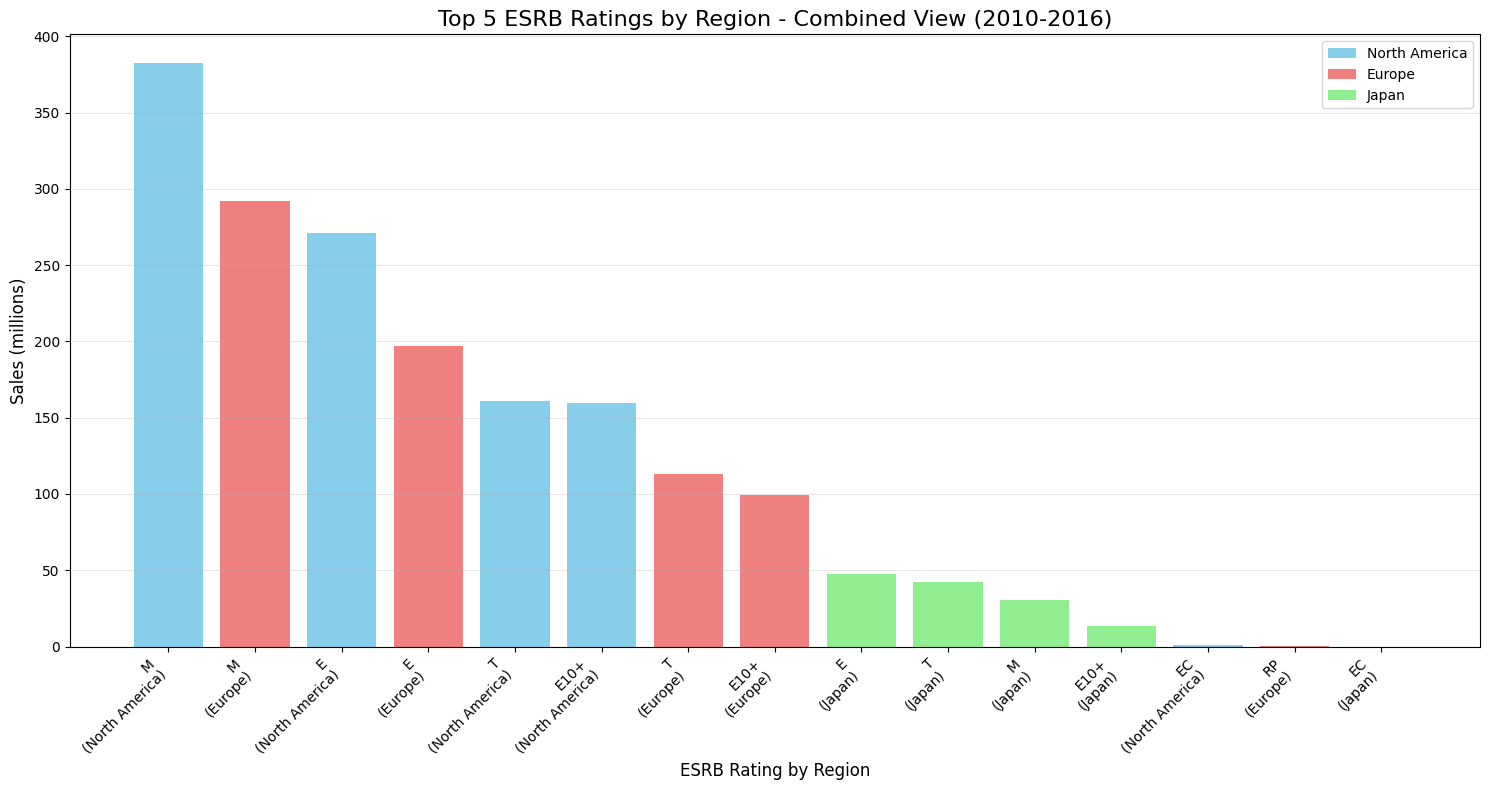

Combined ESRB Rating Sales Data (sorted by sales):
   Rating   Sales         Region
0       M  382.22  North America
5       M  292.04         Europe
1       E  271.15  North America
6       E  197.34         Europe
2       T  160.81  North America
3    E10+  159.38  North America
7       T  113.08         Europe
8    E10+   99.28         Europe
10      E   47.87          Japan
11      T   42.11          Japan
12      M   30.45          Japan
13   E10+   13.22          Japan
4      EC    1.13  North America
9      RP    0.03         Europe
14     EC    0.00          Japan


In [45]:
# Analyze ESRB impact for each region
def create_rating_comparison():
    comparison_df = pd.DataFrame({
        'North America': na_rating,
        'Europe': eu_rating,
        'Japan': jp_rating
    }).fillna(0)
    return comparison_df

print("Rating Sales Comparison (Top 5 per Region):")#comparison data
print(create_rating_comparison())

# Create a comparative ESRB rating analysis
def create_rating_comparison():
    comparison_df = pd.DataFrame({
        'North America': na_rating,
        'Europe': eu_rating,
        'Japan': jp_rating
    }).fillna(0)
    return comparison_df

print("ESRB Rating Sales Comparison (Top 5 per Region):") # comparison data
print(create_rating_comparison())
combined_data = []

for rating, sales in na_rating.items(): # Add North America data
    combined_data.append({'Rating': rating, 'Sales': sales, 'Region': 'North America'})
for rating, sales in eu_rating.items(): # Add Europe data  
    combined_data.append({'Rating': rating, 'Sales': sales, 'Region': 'Europe'})
for rating, sales in jp_rating.items(): # Add Japan data
    combined_data.append({'Rating': rating, 'Sales': sales, 'Region': 'Japan'})

combined_df = pd.DataFrame(combined_data)
combined_df = combined_df.sort_values('Sales', ascending=False) # Sort by sales values (highest to lowest)
# Create the visualization
plt.figure(figsize=(15, 8))
colors = {'North America': 'skyblue', 'Europe': 'lightcoral', 'Japan': 'lightgreen'}
bars = plt.bar(range(len(combined_df)), combined_df['Sales'], 
               color=[colors[region] for region in combined_df['Region']])
plt.title('Top 5 ESRB Ratings by Region - Combined View (2010-2016)', fontsize=16)
plt.xlabel('ESRB Rating by Region', fontsize=12)
plt.ylabel('Sales (millions)', fontsize=12)

# Set x-axis labels
labels = [f"{row['Rating']}\n({row['Region']})" for _, row in combined_df.iterrows()]
plt.xticks(range(len(combined_df)), labels, rotation=45, ha='right')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[region], label=region) for region in colors.keys()]
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the data for reference
print("Combined ESRB Rating Sales Data (sorted by sales):")
print(combined_df)

## Hypothesis Testing

Two statistical tests are evaluated below using $\alpha = 0.05$:

- Average user ratings for Xbox One and PC games.
- Average user ratings for Action and Sports games.

Both tests use two-sided hypotheses to check for any statistically significant difference in means.

In [46]:
# Test 1: XOne vs PC platform user ratings
print("=== Hypothesis Test 1: XOne vs PC Platform User Ratings ===")
print("H0: Average user ratings for XOne and PC are equal")
print("H1: Average user ratings for XOne and PC are different")
print()

# Define the filtered data first
xone_data = data_relevant[data_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_data = data_relevant[data_relevant['platform'] == 'PC']['user_score'].dropna()

# Print summary statistics BEFORE the test
print(f"XOne Platform: mean = {xone_data.mean():.2f}, std = {xone_data.std():.2f}, n = {len(xone_data)}")
print(f"PC Platform: mean = {pc_data.mean():.2f}, std = {pc_data.std():.2f}, n = {len(pc_data)}")
print()

# Run the test
results = st.ttest_ind(xone_data, pc_data, equal_var=False)
print(f"t-statistic: {results.statistic:.3f}")
print(f"p-value: {results.pvalue:.6f}")

# Interpret results
alpha = 0.05
if results.pvalue < alpha:
    print("We reject the null hypothesis: there is a statistically significant difference in average user rating between XOne and PC games")
else:
    print("We fail to reject the null hypothesis: there is not a statistically significant difference in average user rating between XOne and PC games")

=== Hypothesis Test 1: XOne vs PC Platform User Ratings ===
H0: Average user ratings for XOne and PC are equal
H1: Average user ratings for XOne and PC are different

XOne Platform: mean = 6.52, std = 1.38, n = 182
PC Platform: mean = 6.52, std = 1.57, n = 374

t-statistic: 0.025
p-value: 0.980163
We fail to reject the null hypothesis: there is not a statistically significant difference in average user rating between XOne and PC games


In [47]:
# Test 2: Action vs Sports genre user ratings
print("=== Hypothesis Test 2: Action vs Sports Genre User Ratings ===")
print("H0: Average user ratings for Action and Sports genres are equal")
print("H1: Average user ratings for Action and Sports genres are different")
print()

# Define the filtered data first
action_data = data_relevant[data_relevant['genre'] == 'Action']['user_score'].dropna()
sports_data = data_relevant[data_relevant['genre'] == 'Sports']['user_score'].dropna()

# Print summary statistics BEFORE the test
print(f"Action Genre: mean = {action_data.mean():.2f}, std = {action_data.std():.2f}, n = {len(action_data)}")
print(f"Sports Genre: mean = {sports_data.mean():.2f}, std = {sports_data.std():.2f}, n = {len(sports_data)}")
print()

# Run the test
results = st.ttest_ind(action_data, sports_data, equal_var=False)
print(f"t-statistic: {results.statistic:.3f}")
print(f"p-value: {results.pvalue:.6f}")

# Interpret results
alpha = 0.05
if results.pvalue < alpha:
    print("We reject the null hypothesis: there is a statistically significant difference in average user rating between Action and Sports games")
else:
    print("We fail to reject the null hypothesis: there is not a statistically significant difference in average user rating between Action and Sports games")

=== Hypothesis Test 2: Action vs Sports Genre User Ratings ===
H0: Average user ratings for Action and Sports genres are equal
H1: Average user ratings for Action and Sports genres are different

Action Genre: mean = 6.78, std = 1.36, n = 779
Sports Genre: mean = 5.90, std = 1.68, n = 315

t-statistic: 8.253
p-value: 0.000000
We reject the null hypothesis: there is a statistically significant difference in average user rating between Action and Sports games


## General Conclusion

### Overview
We took a general look at video game data from 1980-2016, placing an emphasis on 2010-2016 to keep up with modern trends/habits while balancing a sufficient quantity of data to analayze trends. A lot of older games tended to lack critic/user scores as the system was not present, so there was less to analyze. 

### Critic Scores
Critic scores are worthwhile to note because the correlation between critic score and sales was rather noticeable (difference between an average of `$0.7` million and `$0.4` for for games with and without scores respectively), which might be confounded by the fact that a more popular game is more likely to be reviewed. We did find a moderate correlation between critic scores and sales of 0.336, so that just means it might be worthwhile to get a well-known game critic to review the game early.  

### Platform Trends
In general, platforms seems to maintain meaningful sales for around 8.6 years, which varies on how often newer console models are released and in recent years this lifetime can be extended, but will most likely fall off. The Playstation 3 (PS3) and XBox 360(X360) were very dominant across the last 6 years, holding `$587 million` and `$550 million` in sales respectively. The Playstation 4 (PS4) also shows promise in the last 4 years with `$314 million`. Regions do have noticeable platform preferences, as shown with the XBox in North America (NA), the PlayStation in Europe (EU), and Nintendo handhelds in Japan (JP). This is probably due to Nintendo originating in Japan which resonates stronger with citizens, and the nature of the most popular games of Action/Shooter are more accessible on the XBox and Playstation. Speaking of genre...

### Genre Trends
Action (26.5%) and Shooter (18.9%) games hold the top 2 spots very securely, and consistently rank in the top 2 every year for the last 6 years. While Adventure games have made a resurgence in the last 2 years, it's hard to say if the general population is more attracted to a specific game or the genre as a whole. 

### Regional Comparison
NA and EU seem to prefer Action/Shooter games with M-rated content levels, whereas JP has a more moderate favoritism towrads Role-Playing games and E-rated content. 

For more nuanced comparison, cross-platform games tend to succeed on PS4, X360, and PS3 which are the most popular platforms anyways, as they are compatible (format-wise) with eachother. Through two-tailed statistical analysis, we found that there is not a significant difference in user rating between the XBox One and PC, which means it falls down to personal preference. On the other hand, there is a significant difference between Action and Sport genres. 

### Overall Analysis
For a game to succeed, it should be released on a major/popular platform like the most modern XBox or Playstation, and it seems that cross-platform functionality isn't difficult to implement so it could be released for multiple versions, further expanding the potential market. While Shooter and Action games are extremely popular, that also means the market is extremely saturated, which means it would be much harder to release a popular game unless it is a part of a franchise like Call of Duty. To break into the market, you would most likely need to synthesize interesting aspects from a seperate genre to add an interesting twist, keeping in mind that it must be accessible (adding overly complex puzzles would disuade the average consumer) but have some degree of replayability to retain an audience's engagement over time.